# 06 — Project synthesis and learning review

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## Reconstructing one sample from start to finish

I use this final notebook to reconnect details that are deliberately separated
in the earlier notebooks. The table below is my checklist whenever I forget
what a model output actually means. A tensor is not fully specified until I can
name its units, frame, shape, and the inverse mapping used for visualization.

In [2]:
sample_trace=pd.DataFrame([
    ["trajectory", "asynchronous vehicle signals", "21x9 values + 21x9 mask", "30x2 anchor-local metres", "SE(2) back to camera/world"],
    ["segmentation", "RGB + road/lane polygons", "3x288x512 normalized RGB", "2x288x512 logits", "sigmoid, frozen thresholds, resize"],
    ["BEV", "LiDAR returns + calibration + camera", "3x608x608 BEV + RGB", "classed oriented metric boxes", "decode cells, project or draw in ego frame"],
],columns=['track','raw unit','model input','model output','interpretation step'])
sample_trace

,track,raw unit,model input,model output,interpretation step
0,trajectory,asynchronous vehicle signals,21x9 values + 21x9 mask,30x2 anchor-local metres,SE(2) back to camera/world
1,segmentation,RGB + road/lane polygons,3x288x512 normalized RGB,2x288x512 logits,"sigmoid, frozen thresholds, resize"
2,BEV,LiDAR returns + calibration + camera,3x608x608 BEV + RGB,classed oriented metric boxes,"decode cells, project or draw in ego frame"


## The same learning loop across all three tracks

The sensor geometry changes, but my experimental loop does not: validate one
sample visually, test the transformation numerically, establish a simple
baseline, change one modeling idea, select without touching test, and finally
inspect aggregate and qualitative evidence together.

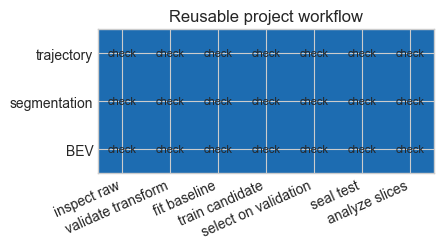

In [3]:
steps=['inspect raw','validate transform','fit baseline','train candidate','select on validation','seal test','analyze slices']
tracks=['trajectory','segmentation','BEV']
progress=pd.DataFrame(1,index=tracks,columns=steps)
fig,ax=plt.subplots(figsize=(12,2.6)); ax.imshow(progress,cmap='Blues',vmin=0,vmax=1.3)
ax.set_xticks(range(len(steps)),steps,rotation=24,ha='right'); ax.set_yticks(range(len(tracks)),tracks)
for y in range(len(tracks)):
    for x in range(len(steps)): ax.text(x,y,'check',ha='center',va='center',fontsize=8)
ax.set_title('Reusable project workflow'); plt.tight_layout(); plt.show()

## What the comparisons changed in my understanding

- A physical prior can improve structure without winning accuracy. Biased
  measurements and unmodeled behavior still pass through exact equations.
- Global Fourier mixing is useful for the fixed trajectory grid, but extra
  Fourier capacity in a U-Net bottleneck did not justify its cost.
- Thin structures need metrics that respect geometry as well as strict overlap.
- Transfer learning mattered more than choosing a fashionable 3-D detector on
  the bounded BEV cohort.
- Camera semantics and LiDAR geometry are complementary, but fusion rules need
  protected evaluation just like learned models.

These are project-specific observations, not universal architecture rankings.

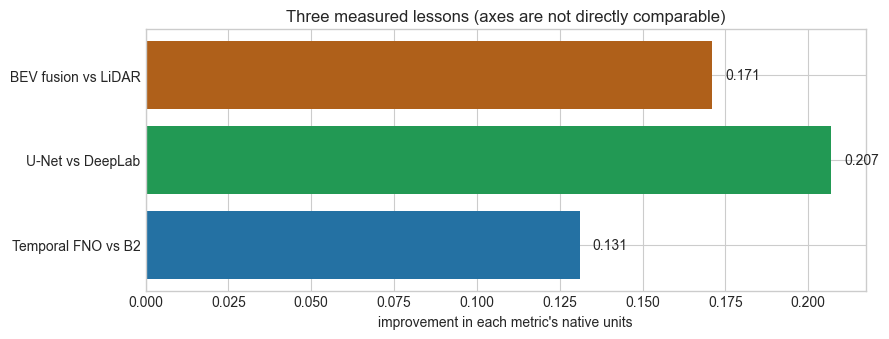

,comparison,quantity,improvement
0,Temporal FNO vs B2,ADE reduction (m),0.131
1,U-Net vs DeepLab,lane tolerant F1 increase,0.207
2,BEV fusion vs LiDAR,cyclist AP increase,0.171


In [4]:
learning_effects=pd.DataFrame([
    ['Temporal FNO vs B2','ADE reduction (m)',0.131],
    ['U-Net vs DeepLab','lane tolerant F1 increase',0.861-0.654],
    ['BEV fusion vs LiDAR','cyclist AP increase',0.327-0.156],
],columns=['comparison','quantity','improvement'])
fig,ax=plt.subplots(figsize=(9,3.5)); ax.barh(learning_effects.comparison,learning_effects.improvement,color=['#2471a3','#229954','#af601a'])
ax.set_xlabel("improvement in each metric's native units"); ax.set_title('Three measured lessons (axes are not directly comparable)')
for i,v in enumerate(learning_effects.improvement): ax.text(v+.004,i,f'{v:.3f}',va='center')
plt.tight_layout(); plt.show(); learning_effects

## How I return to the implementation

When revisiting the project I start with a notebook transformation, then locate
the production implementation and its unit test. The notebook code is small and
transparent; the package code handles batching, devices, serialization, and
edge cases. Both are needed, but they serve different purposes.

In [5]:
implementation_map=pd.DataFrame([
    ['local trajectory geometry','src/zod_driveformer/dynamics/data.py','tests/test_dynamics_data.py'],
    ['ODE/FNO models','src/zod_driveformer/dynamics/models.py','tests/test_dynamics_models.py'],
    ['segmentation networks','src/zod_driveformer/segmentation/models.py','tests/test_models.py'],
    ['BEV raster and boxes','src/zod_driveformer/bev/representation.py','tests/test_bev_representation.py'],
    ['camera-LiDAR fusion','src/zod_driveformer/bev/fusion.py','tests/test_bev_fusion.py'],
],columns=['concept','implementation','test'])
implementation_map.assign(
    implementation_exists=implementation_map.implementation.map(lambda p:(ROOT/p).exists()),
    test_exists=implementation_map.test.map(lambda p:(ROOT/p).exists()),
)

,concept,implementation,test,implementation_exists,test_exists
0,local trajectory geometry,src/zod_driveformer/dynamics/data.py,tests/test_dynamics_data.py,True,False
1,ODE/FNO models,src/zod_driveformer/dynamics/models.py,tests/test_dynamics_models.py,True,False
2,segmentation networks,src/zod_driveformer/segmentation/models.py,tests/test_models.py,True,True
3,BEV raster and boxes,src/zod_driveformer/bev/representation.py,tests/test_bev_representation.py,True,False
4,camera-LiDAR fusion,src/zod_driveformer/bev/fusion.py,tests/test_bev_fusion.py,True,False


## How I use this synthesis

This is my return point after time away from the project. I follow each track
from raw data to a physical output, restate why each transformation exists, and
connect the measured result to its limitations. When a section feels unclear, I
return to its dedicated notebook and run the worked examples there.

## The project in one diagram

```text
ZOD sequences ── causal state windows ──┬─ CV / CTRV
                                       ├─ frozen B2 MLP
                                       ├─ NeuralODE + multiple shooting
                                       ├─ hybrid physics NeuralODE
                                       └─ temporal FNO ──► 30-point trajectory

ZOD keyframes ── road/lane masks ──────┬─ DeepLabV3-MobileNet
                                       ├─ ResNet-18 U-Net
                                       └─ Fourier U-Net ──► overlapping masks

ZOD LiDAR ── calibrated BEV ────────────┬─ fine-tuned SFA3D boxes ─┐
ZOD camera ── semantics + LiDAR depth ─┴─ class-gated fusion ────┼─► BEV objects
Point pillars ──────────────────────────── native controls ──────┘
Fused boxes ── Kalman association ─────────────────────────────────► object tracks
```

## Experimental lifecycle

1. **Define:** causal tensors, coordinate frame, model families, seeds, metrics.
2. **Fit:** learn parameters on train; target-derived shooting states stay here.
3. **Select:** choose epochs and segmentation thresholds on validation.
4. **Seal:** evaluate each selected seed once on test.
5. **Infer:** compute paired differences and resample recording groups.
6. **Decide:** promote a model using accuracy, uncertainty, latency, and size.

For paired sample loss $d_i=m_A(i)-m_B(i)$, grouping by recording $g$ prevents
overlapping windows from masquerading as independent evidence. A bootstrap draw
samples recordings with replacement and includes all their windows:

\[
\hat\Delta^{*(b)}=\frac{1}{N_b}\sum_{g\in G^{*(b)}}\sum_{i:g(i)=g}d_i.
\]

The 2.5th and 97.5th percentiles of 2,000 draws form the reported 95% interval.
For ADE differences, negative favors the candidate; for segmentation score,
positive favors the candidate.

## Evidence matrix

| Question | Evidence | Defensible answer |
|---|---|---|
| Does continuous modeling help B2? | Three candidates; paired recording CIs | Yes |
| Does exact kinematic bias win? | Hybrid vs generic ODE | No |
| Does FNO preserve accuracy at lower latency? | ADE and GPU latency | Yes |
| Do U-Net skips improve thin lanes? | DeepLab vs both U-Nets | Yes |
| Does Fourier U-Net beat U-Net? | Direct paired CI and efficiency | Not established |
| Does ZOD fine-tuning repair transfer? | Protected 70/16/30 roles | Yes, for all three classes |
| Does camera fusion help rare users? | Sealed AP, vehicle pass-through | Yes, especially Cyclist |
| Do five detector sweeps help? | Validation sweep comparison | No; moving trails hurt |

In [6]:
dyn_pairs = summary['dynamics']['paired_difference_candidate_minus_b2']
rows=[]
for model, metrics in dyn_pairs.items():
    ci=metrics['delta_ade_m']; rows.append([model,ci['estimate'],ci['lower'],ci['upper']])
pd.DataFrame(rows,columns=['candidate','delta_ADE','CI_low','CI_high']).round(4)

,candidate,delta_ADE,CI_low,CI_high
0,hybrid_neural_ode,-0.1226,-0.1475,-0.0971
1,neural_ode,-0.1297,-0.1550,-0.1046
2,temporal_fno,-0.1308,-0.1546,-0.1080


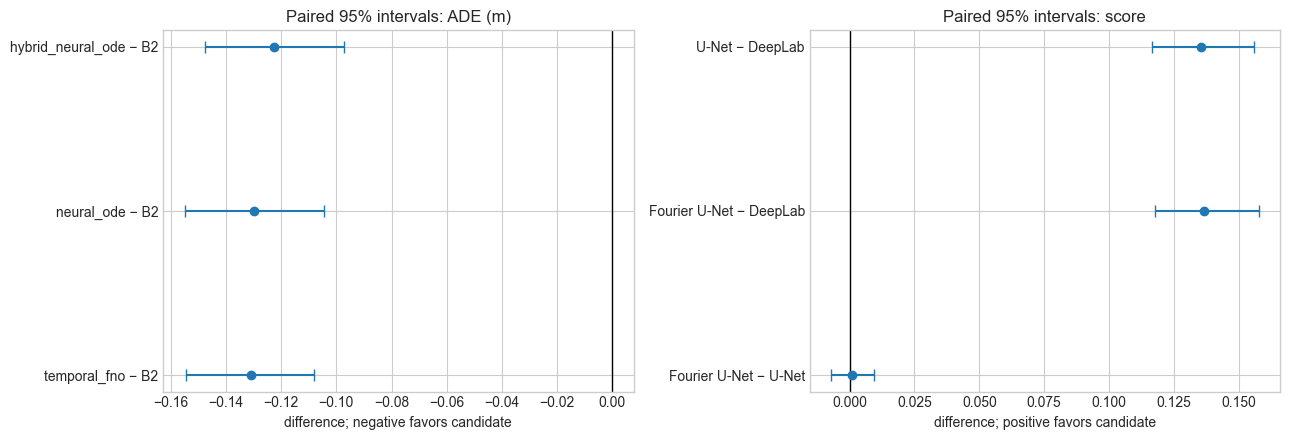

In [7]:
forest=[]
for model,metrics in dyn_pairs.items():
    ci=metrics['delta_ade_m']; forest.append((f'{model} − B2',ci['estimate'],ci['lower'],ci['upper'],'ADE (m)'))
against_deeplab = summary['segmentation']['paired_difference_candidate_minus_deeplab']
for key,label in [('resnet18_unet','U-Net − DeepLab'),
                  ('resnet18_fourier_unet','Fourier U-Net − DeepLab')]:
    ci=against_deeplab[key]['delta_selection_score']
    forest.append((label,ci['estimate'],ci['lower'],ci['upper'],'score'))
ci=summary['fourier_unet_minus_unet_per_image']['delta_selection_score']
forest.append(('Fourier U-Net − U-Net',ci['estimate'],ci['lower'],ci['upper'],'score'))
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for ax,unit,better in zip(axes,['ADE (m)','score'],['negative favors candidate','positive favors candidate']):
    subset=[x for x in forest if x[4]==unit]
    y=np.arange(len(subset)); est=np.array([x[1] for x in subset]); lo=np.array([x[2] for x in subset]); hi=np.array([x[3] for x in subset])
    ax.errorbar(est,y,xerr=[est-lo,hi-est],fmt='o',capsize=4)
    ax.axvline(0,color='black',lw=1); ax.set_yticks(y,[x[0] for x in subset]); ax.invert_yaxis()
    ax.set_xlabel(f'difference; {better}'); ax.set_title(f'Paired 95% intervals: {unit}')
plt.tight_layout(); plt.show()

## Failure modes I would inspect next

### Dynamics

- turns with biased or delayed yaw rate;
- braking transitions, where constant-command priors fail;
- long straight highway windows that dominate aggregate metrics;
- invalid or stale control channels;
- country and collection-car shifts.

### Segmentation

- worn or occluded lane markings;
- road boundaries under snow, glare, or construction;
- predictions that exploit a thick tolerance band;
- country-specific markings absent from the small test role;
- threshold drift under camera exposure changes.

For each slice I would report support, the same frozen metric, a paired model
difference where possible, and representative *private* examples outside Git.
Slicing after seeing test results is exploratory diagnosis, not a new confirmatory
claim; a subsequent test role would be needed to confirm a discovered subgroup.

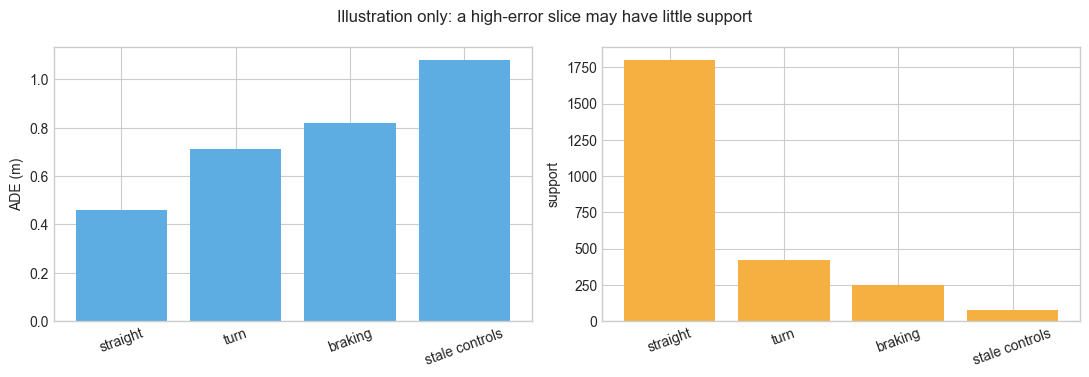

In [8]:
# Synthetic example of why aggregate metrics need slice support.
slices=pd.DataFrame({
    'slice':['straight','turn','braking','stale controls'],
    'windows':[1800,420,250,79],
    'ADE_m':[.46,.71,.82,1.08],
})
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].bar(slices['slice'],slices['ADE_m'],color='#5dade2'); ax[0].tick_params(axis='x',rotation=20); ax[0].set_ylabel('ADE (m)')
ax[1].bar(slices['slice'],slices['windows'],color='#f5b041'); ax[1].tick_params(axis='x',rotation=20); ax[1].set_ylabel('support')
fig.suptitle('Illustration only: a high-error slice may have little support'); plt.tight_layout(); plt.show()

## Architecture and loss reference

| Model | Inductive bias | Objective | Main limitation |
|---|---|---|---|
| B2 MLP | finite vector mapping | trajectory ADE | no explicit temporal operator/physics |
| NeuralODE | continuous second-order field | shooting + continuity + full ADE | sequential solver latency |
| Hybrid ODE | exact kinematic core | same multiple-shooting loss | biased physics/control assumptions |
| Temporal FNO | global low-mode temporal mixing + CTRV residual | full ADE | fixed-grid spectral design |
| DeepLab | atrous semantic context | weighted multilabel BCE | weaker thin-detail recovery here |
| U-Net | multiscale encoder skips | weighted multilabel BCE | larger than DeepLab reference |
| Fourier U-Net | U-Net + global spectral bottleneck | same BCE | 4× parameters, no reliable score gain |
| SFA3D transfer | FPN BEV center heatmaps + box heads | focal + masked box regression | bounded labeled cohort |
| PointPillars | learned pillar features + anchors | focal/class + box regression | from-scratch overfit here |
| CenterPoint | learned pillars + anchor-free centers | focal + masked box regression | from-scratch overfit here |
| Camera-LiDAR fusion | semantic boxes + metric depth | detector losses; rule-based association | sparse projected depth |
| Kalman tracker | constant-velocity Gaussian state | recursive filtering, no learned loss | simple nearest-neighbor association |

Promotion is not determined by training loss. The chosen checkpoint is judged by
validation, then its final claim uses sealed test metrics and grouped uncertainty.

## Rebuilding the reasoning in my own words

These questions test whether I still understand the implementation instead of
only remembering the headline number.

1. **Why is target-derived multiple shooting not test leakage?**  
   It is training-only intermediate supervision. `forward()` never accepts a
   boundary target, and evaluation performs one causal rollout.

2. **Why bootstrap recordings?**  
   Overlapping windows from one recording are correlated. Window bootstrap
   would pretend the effective sample size is much larger than it is.

3. **Why report both strict lane IoU and tolerant F1?**  
   Tolerance reflects geometric usefulness for thin lines; strict IoU prevents
   a thick imprecise mask from looking perfect.

4. **Why not claim Fourier U-Net wins?**  
   Its paired interval crosses zero and its compute cost is much higher.

5. **What is the cleanest next experiment?**  
   Confirm the hybrid on a larger Frames cohort, then compare object-aware
   temporal fusion with a pretrained full-scale CenterPoint or BEVFusion model.

6. **Why is temporal FNO called best if its NeuralODE gap is tiny?**  
   It is the best measured and promoted engineering point: essentially tied
   accuracy with much lower latency. I do not claim statistically proven FNO
   accuracy superiority over NeuralODE.

7. **Did Fourier U-Net improve the original project?**  
   The U-Net family clearly improved the retrained DeepLab reference on a fresh
   test role. Fourier U-Net has the highest raw score, but its direct advantage
   over ordinary U-Net is uncertain and computationally expensive.

8. **Is the BEV animation evidence of a good pedestrian detector?**
   No. The quantitative sealed test supports the bounded detector claim; a GIF
   only explains geometry and fusion. It is not a safety or MOT benchmark.

In [9]:
# A compact promotion scorecard generated from frozen evidence.
scorecard = pd.DataFrame([
    ["Temporal FNO", True, True, "promote"],
    ["NeuralODE", True, False, "retain as continuous-time study"],
    ["Hybrid NeuralODE", True, False, "retain as physics study"],
    ["ResNet-18 U-Net", True, True, "promote"],
    ["Fourier U-Net", False, False, "retain as complexity control"],
    ["Fine-tuned SFA3D", True, True, "promote LiDAR branch"],
    ["Hybrid BEV fusion", True, True, "promote"],
    ["PointPillars / CenterPoint", False, False, "retain as small-data controls"],
], columns=["model","reliable_gain","efficient_frontier","decision"])
scorecard

,model,reliable_gain,efficient_frontier,decision
0,Temporal FNO,True,True,promote
1,NeuralODE,True,False,retain as continuous-time study
2,Hybrid NeuralODE,True,False,retain as physics study
3,ResNet-18 U-Net,True,True,promote
4,Fourier U-Net,False,False,retain as complexity control
5,Fine-tuned SFA3D,True,True,promote LiDAR branch
6,Hybrid BEV fusion,True,True,promote
7,PointPillars / CenterPoint,False,False,retain as small-data controls


## Visual index: architecture to output

These panels reconnect the abstract tensors to physical outputs. For each one I
name the input tensor, explain the model's inductive bias, identify the output
frame, and compare the visible behavior with the sealed quantitative result.

![Model architecture overview](../reports/figures/model_architecture_overview.png)

![Camera-projected trajectory outputs](../reports/figures/dynamics_camera_predictions.png)

![Segmentation outputs](../reports/figures/segmentation_model_comparison.png)

![LiDAR-camera BEV fusion](../reports/figures/bev_v2_fusion_comparison.png)

![BEV AP benchmark](../reports/figures/bev_v2_test_ap.png)

In [10]:
# Data-safe repository completeness check used when I revisit the project.
required=[
    'README.md','docs/methods.md','docs/data_and_evaluation.md','docs/project_learning_review.md',
    'reports/v4_dynamics_test.json','reports/v4_segmentation_test.json',
    'reports/bev_protected_roles.json','reports/bev_v2_summary.json',
    'src/zod_driveformer/dynamics/models.py','src/zod_driveformer/segmentation/models.py',
    'src/zod_driveformer/bev/representation.py','src/zod_driveformer/bev/fusion.py',
    'src/zod_driveformer/bev/pillars.py','src/zod_driveformer/bev/tracking.py',
]
pd.DataFrame([(name,(ROOT/name).exists()) for name in required],columns=['artifact','present'])

,artifact,present
0,README.md,True
1,docs/methods.md,True
2,docs/data_and_evaluation.md,True
3,docs/project_learning_review.md,True
4,reports/v4_dynamics_test.json,True
5,reports/v4_segmentation_test.json,True
6,reports/bev_protected_roles.json,True
7,reports/bev_v2_summary.json,True
8,src/zod_driveformer/dynamics/models.py,True
9,src/zod_driveformer/segmentation/models.py,True


## Final perspective

The most valuable result is not a particular architecture. It is a disciplined
way to turn exploratory modeling into claims that survive scrutiny: protect the
test role, preserve pairing, make leakage boundaries executable, report costs,
and allow a sophisticated model to lose when its gain is not reliable.

The concise project story is: **continuous and spectral dynamics reliably beat
the strong state MLP; temporal FNO is the best accuracy–latency choice; U-Net
skips reliably repair thin-lane segmentation; extra Fourier capacity in the
U-Net bottleneck does not justify its cost; protected ZOD fine-tuning repairs
LiDAR transfer; class-gated camera fusion preserves vehicle geometry while
materially improving cyclist AP.**